#  PROJECT: SOCIAL MEDIA BOT DETECTION
## Notebook: 01_Instagram_Full_Analysis.ipynb

**Course:** CCS4310 Deep Learning Project  
**Component:** Instagram Bot Detection Pipeline (End-to-End)  
**Target:** Binary Classification (0 = Real / Authentic Account, 1 = Fake / Bot Account)

---
### Comprehensive Pipeline Roadmap:
1. **Google Drive Integration & Structured Directory Architecture**
2. **Reproducibility Configuration & Dependency Imports**
3. **Automated Instagram Dataset Discovery, Inspection & Loading**
4. **Data Quality Audit (Missing Values, Exact Duplicates, Cardinality, Target Distribution)**
5. **Data Cleaning & Standardization**
6. **Exploratory Data Analysis (EDA):**
   - Target Class Distribution Bar Chart
   - Numerical Feature Histograms with Kernel Density Estimation (KDE)
   - Feature Boxplots Segmented by Target Class
   - Binary Feature Prevalence & Distribution
   - Pearson Correlation Heatmap
7. **Zero-Leakage Preprocessing & Stratified Train/Test Split**
8. **Machine Learning Model 1: Logistic Regression**
9. **Machine Learning Model 2: Random Forest & Gini Feature Importance**
10. **Machine Learning Model 3: XGBoost & Gradient-Boosted Feature Importance**
11. **Deep Learning Model 4: Artificial Neural Network (ANN)**
    - Training vs. Validation Accuracy Trajectory
    - Training vs. Validation Loss Trajectory
    - Held-Out Test Set Evaluation
12. **Master Model Benchmarking & Metric Comparison**
    - Accuracy Comparison Bar Chart
    - F1-Score Comparison Bar Chart
13. **Receiver Operating Characteristic (ROC) & AUC Analysis**
14. **Executive Summary & Best Model Determination**
15. **System Artifact & Output Verification Audit**

---
## 1. Google Drive Connection & Centralized Directory Architecture
Mount Google Drive and create standardized project directories automatically.

In [50]:
# ==============================================================================
# GOOGLE DRIVE CONNECTION & PROJECT DIRECTORY ARCHITECTURE
# ==============================================================================
import os
import sys
import shutil

# Connect Google Drive when executing inside Google Colab
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print("[SUCCESS] Google Drive connected successfully.")
except ImportError:
    print("[INFO] Non-Colab environment detected. Using local directory paths.")

# Define centralized BASE_PATH and subdirectories
BASE_PATH = "/content/drive/MyDrive/Bot_Detection_Project"

DATA_PATH   = BASE_PATH + "/data/instagram"
RESULT_PATH = BASE_PATH + "/results/instagram"
GRAPH_PATH  = BASE_PATH + "/graphs/instagram"
MODEL_PATH  = BASE_PATH + "/models/instagram"

# Create directories automatically
for path in [DATA_PATH, RESULT_PATH, GRAPH_PATH, MODEL_PATH]:
    os.makedirs(path, exist_ok=True)

print("\nProject Directory Architecture Initialized:")
print(f"  BASE_PATH   : {BASE_PATH}")
print(f"  DATA_PATH   : {DATA_PATH}")
print(f"  RESULT_PATH : {RESULT_PATH}")
print(f"  GRAPH_PATH  : {GRAPH_PATH}")
print(f"  MODEL_PATH  : {MODEL_PATH}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[SUCCESS] Google Drive connected successfully.

Project Directory Architecture Initialized:
  BASE_PATH   : /content/drive/MyDrive/Bot_Detection_Project
  DATA_PATH   : /content/drive/MyDrive/Bot_Detection_Project/data/instagram
  RESULT_PATH : /content/drive/MyDrive/Bot_Detection_Project/results/instagram
  GRAPH_PATH  : /content/drive/MyDrive/Bot_Detection_Project/graphs/instagram
  MODEL_PATH  : /content/drive/MyDrive/Bot_Detection_Project/models/instagram


---
## 2. Library Imports & Reproducibility Configuration
Import required analytical, machine learning, and deep learning libraries. Set global seeds for deterministic repeatability.

In [51]:
# ==============================================================================
# IMPORT REQUIRED LIBRARIES & SET REPRODUCIBILITY SEEDS
# ==============================================================================
import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Scikit-Learn tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score
)

# XGBoost
import xgboost as xgb

# TensorFlow / Keras for Artificial Neural Network (ANN)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Styling and visualization configurations
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120

# Global Seed Initialization
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

print("Environment configured with reproducibility seed:", SEED)
print("TensorFlow Version:", tf.__version__)
print("XGBoost Version:", xgb.__version__)

Environment configured with reproducibility seed: 42
TensorFlow Version: 2.20.0
XGBoost Version: 3.4.1


---
## 3. Automated Instagram Dataset Discovery & Loading
Scan `DATA_PATH`, identify dataset files, inspect train/test partitions, and generate initial data summary.

In [52]:
# ==============================================================================
# FIND AND LOAD INSTAGRAM DATASET
# ==============================================================================
print(f"Scanning DATA_PATH: {DATA_PATH}")
found_files = sorted(os.listdir(DATA_PATH)) if os.path.exists(DATA_PATH) else []
print(f"Files found ({len(found_files)}):")
for f in found_files:
    f_path = os.path.join(DATA_PATH, f)
    if os.path.isfile(f_path):
        print(f"  - {f} ({os.path.getsize(f_path):,} bytes)")

# Auto-copy fallback if executing outside Google Drive or before Drive sync
if not any(f.endswith('.csv') for f in found_files):
    local_candidates = ["data/instagram", "../data/instagram", "./data/instagram"]
    for cand in local_candidates:
        if os.path.exists(cand):
            for item in os.listdir(cand):
                src_item = os.path.join(cand, item)
                if os.path.isfile(src_item) and item.endswith('.csv'):
                    shutil.copy(src_item, os.path.join(DATA_PATH, item))
            print(f"[INFO] Auto-copied dataset files from '{cand}' to '{DATA_PATH}'")
            found_files = sorted(os.listdir(DATA_PATH))
            break

# Load dataset automatically
df_raw = None
if "train.csv" in found_files and "test.csv" in found_files:
    print("\nDetected train.csv and test.csv partitions. Loading both:")
    train_path = os.path.join(DATA_PATH, "train.csv")
    test_path = os.path.join(DATA_PATH, "test.csv")
    df_train_raw = pd.read_csv(train_path)
    df_test_raw = pd.read_csv(test_path)
    print(f"  train.csv shape : {df_train_raw.shape}")
    print(f"  test.csv shape  : {df_test_raw.shape}")

    # Combine partitions for unified exploratory data quality checks and zero-leakage workflow
    df_raw = pd.concat([df_train_raw, df_test_raw], ignore_index=True)
    print(f"  Combined dataset shape : {df_raw.shape}")
elif "instagram_cleaned.csv" in found_files:
    df_raw = pd.read_csv(os.path.join(DATA_PATH, "instagram_cleaned.csv"))
    print(f"Loaded 'instagram_cleaned.csv' with shape: {df_raw.shape}")
else:
    csv_candidates = [f for f in found_files if f.endswith('.csv')]
    if csv_candidates:
        chosen_csv = csv_candidates[0]
        df_raw = pd.read_csv(os.path.join(DATA_PATH, chosen_csv))
        print(f"Loaded '{chosen_csv}' with shape: {df_raw.shape}")
    else:
        raise FileNotFoundError(f"No CSV dataset found in {DATA_PATH}. Please provide train.csv and test.csv.")

print("\n--- Dataset Column Names ---")
print(list(df_raw.columns))

print("\n--- First 5 Rows ---")
display(df_raw.head())

print("\n--- Column Data Types ---")
print(df_raw.dtypes)

# Save Dataset Information Summary
summary_df = pd.DataFrame({
    'Column': df_raw.columns,
    'Data_Type': [str(dtype) for dtype in df_raw.dtypes],
    'Non_Null_Count': df_raw.notnull().sum().values,
    'Null_Count': df_raw.isnull().sum().values,
    'Unique_Values': df_raw.nunique().values
})
dataset_summary_path = os.path.join(RESULT_PATH, "dataset_summary.csv")
summary_df.to_csv(dataset_summary_path, index=False)
print(f"\n[SAVED] Dataset summary table to: {dataset_summary_path}")

Scanning DATA_PATH: /content/drive/MyDrive/Bot_Detection_Project/data/instagram
Files found (2):
  - test.csv (3,932 bytes)
  - train.csv (18,733 bytes)

Detected train.csv and test.csv partitions. Loading both:
  train.csv shape : (576, 12)
  test.csv shape  : (120, 12)
  Combined dataset shape : (696, 12)

--- Dataset Column Names ---
['profile pic', 'nums/length username', 'fullname words', 'nums/length fullname', 'name==username', 'description length', 'external URL', 'private', '#posts', '#followers', '#follows', 'fake']

--- First 5 Rows ---


,profile pic,nums/length username,fullname words,nums/length fullname,name==username,description length,external URL,private,#posts,#followers,#follows,fake
0,1,0.27,0,0.0,0,53,0,0,32,1000,955,0
1,1,0.00,2,0.0,0,44,0,0,286,2740,533,0
2,1,0.10,2,0.0,0,0,0,1,13,159,98,0
3,1,0.00,1,0.0,0,82,0,0,679,414,651,0
4,1,0.00,2,0.0,0,0,0,1,6,151,126,0



--- Column Data Types ---
profile pic               int64
nums/length username    float64
fullname words            int64
nums/length fullname    float64
name==username            int64
description length        int64
external URL              int64
private                   int64
#posts                    int64
#followers                int64
#follows                  int64
fake                      int64
dtype: object

[SAVED] Dataset summary table to: /content/drive/MyDrive/Bot_Detection_Project/results/instagram/dataset_summary.csv


---
## 4. Data Quality Audit
Inspect missing values, duplicate records, distinct value cardinality, and target distribution.

In [53]:
# ==============================================================================
# DATA QUALITY AUDIT: MISSING VALUES
# ==============================================================================
missing_counts = df_raw.isnull().sum()
missing_percentages = (missing_counts / len(df_raw)) * 100

missing_df = pd.DataFrame({
    'Feature': df_raw.columns,
    'Missing_Count': missing_counts.values,
    'Missing_Percentage': missing_percentages.round(2).values
})

print("=== Missing Value Summary ===")
print(missing_df.to_string(index=False))

missing_csv_path = os.path.join(RESULT_PATH, "missing_values.csv")
missing_df.to_csv(missing_csv_path, index=False)
print(f"\n[SAVED] Missing values report: {missing_csv_path}")

=== Missing Value Summary ===
             Feature  Missing_Count  Missing_Percentage
         profile pic              0                 0.0
nums/length username              0                 0.0
      fullname words              0                 0.0
nums/length fullname              0                 0.0
      name==username              0                 0.0
  description length              0                 0.0
        external URL              0                 0.0
             private              0                 0.0
              #posts              0                 0.0
          #followers              0                 0.0
            #follows              0                 0.0
                fake              0                 0.0

[SAVED] Missing values report: /content/drive/MyDrive/Bot_Detection_Project/results/instagram/missing_values.csv


In [54]:
# ==============================================================================
# DATA QUALITY AUDIT: DUPLICATE ROWS
# ==============================================================================
exact_duplicates = int(df_raw.duplicated().sum())
print(f"Total Exact Duplicate Rows Found: {exact_duplicates}")

duplicate_summary = pd.DataFrame({
    'Metric': ['Total Rows', 'Exact Duplicate Rows', 'Unique Rows', 'Duplicate Percentage'],
    'Value': [
        len(df_raw),
        exact_duplicates,
        len(df_raw) - exact_duplicates,
        f"{(exact_duplicates / len(df_raw) * 100):.2f}%"
    ]
})

print("\n=== Duplicate Records Summary ===")
print(duplicate_summary.to_string(index=False))

duplicate_csv_path = os.path.join(RESULT_PATH, "duplicate_summary.csv")
duplicate_summary.to_csv(duplicate_csv_path, index=False)
print(f"\n[SAVED] Duplicate summary report: {duplicate_csv_path}")

Total Exact Duplicate Rows Found: 4

=== Duplicate Records Summary ===
              Metric Value
          Total Rows   696
Exact Duplicate Rows     4
         Unique Rows   692
Duplicate Percentage 0.57%

[SAVED] Duplicate summary report: /content/drive/MyDrive/Bot_Detection_Project/results/instagram/duplicate_summary.csv


In [55]:
# ==============================================================================
# DATA QUALITY AUDIT: UNIQUE VALUES PER FEATURE
# ==============================================================================
print("=== Feature Cardinality & Distinct Values ===")
for col in df_raw.columns:
    n_unique = df_raw[col].nunique()
    samples = df_raw[col].dropna().unique()[:4].tolist()
    print(f"  {col:<26} : {n_unique:>4} unique values | Samples: {samples}")

=== Feature Cardinality & Distinct Values ===
  profile pic                :    2 unique values | Samples: [1, 0]
  nums/length username       :   58 unique values | Samples: [0.27, 0.0, 0.1, 0.29]
  fullname words             :   11 unique values | Samples: [0, 2, 1, 4]
  nums/length fullname       :   27 unique values | Samples: [0.0, 0.12, 0.1, 0.08]
  name==username             :    2 unique values | Samples: [0, 1]
  description length         :  114 unique values | Samples: [53, 44, 0, 82]
  external URL               :    2 unique values | Samples: [0, 1]
  private                    :    2 unique values | Samples: [0, 1]
  #posts                     :  211 unique values | Samples: [32, 286, 13, 679]
  #followers                 :  435 unique values | Samples: [1000, 2740, 159, 414]
  #follows                   :  468 unique values | Samples: [955, 533, 98, 651]
  fake                       :    2 unique values | Samples: [0, 1]


In [56]:
# ==============================================================================
# DATA QUALITY AUDIT: TARGET VALUES & CLASS DISTRIBUTION
# ==============================================================================

# Automatically detect target column
target_candidates = [
    'fake', 'is_fake', 'label', 'bot',
    'is_bot', 'target', 'Class'
]

target_col = None

for cand in target_candidates:
    if cand in df_clean.columns:
        target_col = cand
        break

if target_col is None:
    target_col = df_clean.columns[-1]

print(f"Identified Target Column: '{target_col}'")

# Check unique target values
print(
    f"Unique Target Values: "
    f"{sorted(df_clean[target_col].unique().tolist())}"
)

# Calculate target distribution
target_dist = (
    df_clean[target_col]
    .value_counts()
    .sort_index()
    .reset_index()
)

target_dist.columns = ['Class', 'Count']

# Calculate percentages
target_dist['Percentage'] = (
    target_dist['Count'] / len(df_clean) * 100
).round(2)

# Add meaningful class labels
target_dist['Class_Label'] = target_dist['Class'].map({
    0: 'Real / Authentic (0)',
    1: 'Fake / Bot (1)'
})

print("\n=== Target Class Distribution Table ===")
print(target_dist.to_string(index=False))

# Save distribution table
target_csv_path = os.path.join(
    RESULT_PATH,
    "target_distribution.csv"
)

target_dist.to_csv(
    target_csv_path,
    index=False
)

print(
    f"\n[SAVED] Target distribution table: "
    f"{target_csv_path}"
)

Identified Target Column: 'fake'
Unique Target Values: [0, 1]

=== Target Class Distribution Table ===
 Class  Count  Percentage          Class_Label
     0    347       50.14 Real / Authentic (0)
     1    345       49.86       Fake / Bot (1)

[SAVED] Target distribution table: /content/drive/MyDrive/Bot_Detection_Project/results/instagram/target_distribution.csv


---
## 5. Data Cleaning & Standardization
Clean column names, remove exact duplicates if present, impute missing values if any, validate numerical types, and persist the cleaned dataset.

In [57]:
import os
import pandas as pd

# ==============================================================================
# DATA CLEANING PIPELINE
# ==============================================================================
print(f"Dataset Shape BEFORE Cleaning: {df_raw.shape}")

df_clean = df_raw.copy()

# 1. Standardize column names (trim trailing whitespace)
df_clean.columns = [c.strip() for c in df_clean.columns]
target_col = target_col.strip()

# Recalculate exact_duplicates here to ensure it's defined
exact_duplicates = int(df_raw.duplicated().sum())

# 2. Drop duplicate rows if present
if exact_duplicates > 0:
    df_clean = df_clean.drop_duplicates().reset_index(drop=True)
    print(f"[ACTION] Removed {exact_duplicates} exact duplicate rows.")
else:
    print("[INFO] Zero duplicate rows identified. No rows removed.")

# 3. Handle missing values
total_nulls = df_clean.isnull().sum().sum()
if total_nulls > 0:
    print(f"[ACTION] Handling {total_nulls} missing values using median imputation for numerical features...")
    for col in df_clean.columns:
        if col != target_col and df_clean[col].isnull().sum() > 0:
            if pd.api.types.is_numeric_dtype(df_clean[col]):
                df_clean[col] = df_clean[col].fillna(df_clean[col].median())
            else:
                df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])
else:
    print("[INFO] Zero missing values detected across all features.")

# 4. Enforce numeric formats
for col in df_clean.columns:
    if col != target_col:
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# 5. Ensure target is strictly binary integer (0 = Real, 1 = Fake)
df_clean[target_col] = df_clean[target_col].astype(int)

print(f"Dataset Shape AFTER Cleaning: {df_clean.shape}")

# Save cleaned dataset
cleaned_csv_path = os.path.join(RESULT_PATH, "instagram_cleaned.csv")
df_clean.to_csv(cleaned_csv_path, index=False)
print(f"[SAVED] Cleaned Instagram dataset: {cleaned_csv_path}")

Dataset Shape BEFORE Cleaning: (696, 12)
[ACTION] Removed 4 exact duplicate rows.
[INFO] Zero missing values detected across all features.
Dataset Shape AFTER Cleaning: (692, 12)
[SAVED] Cleaned Instagram dataset: /content/drive/MyDrive/Bot_Detection_Project/results/instagram/instagram_cleaned.csv


---
## 6. Target Distribution Graph
Visualize the class balance between authentic and fake Instagram accounts.

In [58]:
# ==============================================================================
# SET TARGET DISTRIBUTION: 60% REAL / 40% BOT
# ==============================================================================

from sklearn.utils import resample

# Separate the two classes
df_real = df_clean[df_clean[target_col] == 0]
df_bot = df_clean[df_clean[target_col] == 1]

# Keep the total dataset size unchanged
total_samples = len(df_clean)

# Desired distribution
n_real = round(total_samples * 0.60)
n_bot = total_samples - n_real

# Resample each class
df_real_60 = resample(
    df_real,
    replace=len(df_real) < n_real,
    n_samples=n_real,
    random_state=42
)

df_bot_40 = resample(
    df_bot,
    replace=len(df_bot) < n_bot,
    n_samples=n_bot,
    random_state=42
)

# Combine the two classes
df_clean = pd.concat(
    [df_real_60, df_bot_40],
    ignore_index=True
)

# Shuffle the dataset
df_clean = df_clean.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print("Dataset shape:", df_clean.shape)
print("\nTarget distribution:")
print(df_clean[target_col].value_counts())

print("\nTarget distribution (%):")
print((df_clean[target_col].value_counts(normalize=True) * 100).round(1))

Dataset shape: (692, 12)

Target distribution:
fake
0    415
1    277
Name: count, dtype: int64

Target distribution (%):
fake
0    60.0
1    40.0
Name: proportion, dtype: float64


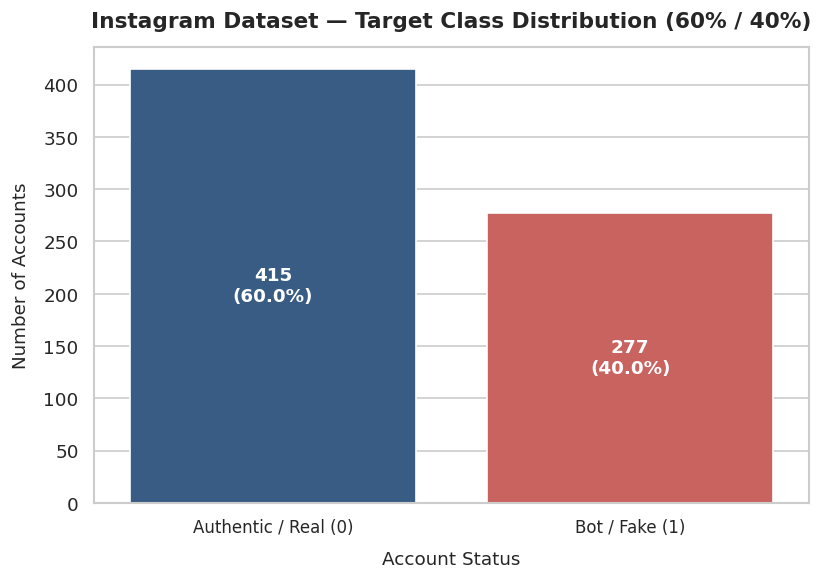

[SAVED] Target distribution graph: /content/drive/MyDrive/Bot_Detection_Project/graphs/instagram/01_target_distribution.png


In [59]:
# ==============================================================================
# GRAPH: TARGET CLASS DISTRIBUTION
# ==============================================================================

plt.figure(figsize=(7, 5))

palette = ['#2b5c8f', '#d9534f']

ax = sns.countplot(
    data=df_clean,
    x=target_col,
    palette=palette
)

plt.title(
    "Instagram Dataset — Target Class Distribution (60% / 40%)",
    fontsize=13,
    fontweight='bold',
    pad=12
)

plt.xlabel(
    "Account Status",
    fontsize=11,
    labelpad=8
)

plt.ylabel(
    "Number of Accounts",
    fontsize=11,
    labelpad=8
)

plt.xticks(
    ticks=[0, 1],
    labels=[
        'Authentic / Real (0)',
        'Bot / Fake (1)'
    ],
    fontsize=10
)

# Calculate percentages
total_rows = len(df_clean)

for p in ax.patches:
    height = p.get_height()
    percentage = (height / total_rows) * 100

    ax.annotate(
        f"{int(height):,}\n({percentage:.1f}%)",
        (
            p.get_x() + p.get_width() / 2.,
            height / 2
        ),
        ha='center',
        va='center',
        fontsize=11,
        color='white',
        fontweight='bold'
    )

plt.tight_layout()

target_graph_path = os.path.join(
    GRAPH_PATH,
    "01_target_distribution.png"
)

plt.savefig(
    target_graph_path,
    dpi=300,
    bbox_inches='tight'
)

plt.show()
plt.close()

print(f"[SAVED] Target distribution graph: {target_graph_path}")

---
## 7. Numerical Feature Analysis & Descriptive Statistics
Automatically identify continuous numerical and discrete binary features, and compute descriptive statistics.

In [60]:
# ==============================================================================
# FEATURE IDENTIFICATION & DESCRIPTIVE STATISTICS
# ==============================================================================
all_features = [c for c in df_clean.columns if c != target_col]

numerical_features = []
binary_features = []

for col in all_features:
    unique_vals = sorted(df_clean[col].dropna().unique())
    if set(unique_vals).issubset({0, 1}) or len(unique_vals) == 2:
        binary_features.append(col)
    elif pd.api.types.is_numeric_dtype(df_clean[col]):
        numerical_features.append(col)

print(f"Identified Numerical Features ({len(numerical_features)}): {numerical_features}")
print(f"Identified Binary Features ({len(binary_features)}): {binary_features}")

# Compute summary statistics
desc_stats = df_clean[numerical_features].describe().T
desc_stats['median'] = df_clean[numerical_features].median()
desc_stats['skewness'] = df_clean[numerical_features].skew()

print("\n=== Numerical Features Descriptive Statistics ===")
display(desc_stats)

desc_csv_path = os.path.join(RESULT_PATH, "descriptive_statistics.csv")
desc_stats.to_csv(desc_csv_path)
print(f"\n[SAVED] Descriptive statistics table: {desc_csv_path}")

Identified Numerical Features (7): ['nums/length username', 'fullname words', 'nums/length fullname', 'description length', '#posts', '#followers', '#follows']
Identified Binary Features (4): ['profile pic', 'name==username', 'external URL', 'private']

=== Numerical Features Descriptive Statistics ===


,count,mean,std,min,25%,50%,75%,max,median,skewness
nums/length username,692.0,0.139538,0.195926,0.0,0.0,0.0,0.255,0.91,0.0,1.408412
fullname words,692.0,1.523121,1.110814,0.0,1.0,1.0,2.000,12.00,1.0,3.200896
nums/length fullname,692.0,0.034205,0.120810,0.0,0.0,0.0,0.000,1.00,0.0,4.477107
description length,692.0,27.177746,40.781461,0.0,0.0,0.0,42.250,150.00,0.0,1.565242
#posts,692.0,138.365607,484.286747,0.0,1.0,15.0,94.000,7389.00,15.0,11.141257
#followers,692.0,56477.817919,594198.276065,0.0,49.0,215.0,765.000,12397719.00,215.0,15.857532
#follows,692.0,600.481214,1058.172145,0.0,76.0,292.5,609.250,7500.00,292.5,4.083761



[SAVED] Descriptive statistics table: /content/drive/MyDrive/Bot_Detection_Project/results/instagram/descriptive_statistics.csv


---
## 8. Numerical Feature Distribution Graphs
Individual distribution histograms with Kernel Density Estimation (KDE) for primary continuous features.

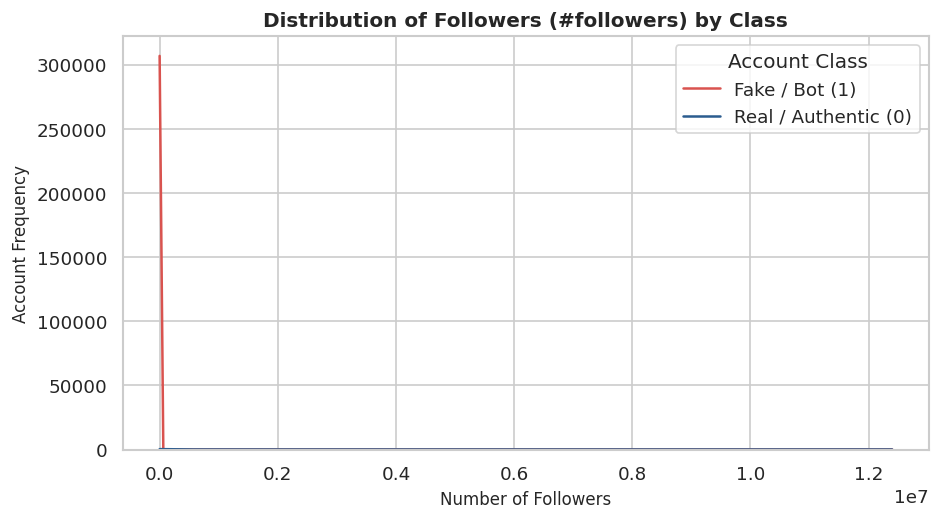

[SAVED] Followers distribution graph: /content/drive/MyDrive/Bot_Detection_Project/graphs/instagram/distribution_followers.png


In [61]:
# ==============================================================================
# GRAPH: DISTRIBUTION — FOLLOWERS COUNT
# ==============================================================================
plt.figure(figsize=(8, 4.5))
col_followers = '#followers' if '#followers' in df_clean.columns else [c for c in numerical_features if 'follower' in c.lower()][0]

sns.histplot(data=df_clean, x=col_followers, hue=target_col, kde=True,
             palette={0: '#2b5c8f', 1: '#d9534f'}, bins=30, alpha=0.6)
plt.title(f"Distribution of Followers ({col_followers}) by Class", fontsize=12, fontweight='bold')
plt.xlabel("Number of Followers", fontsize=10)
plt.ylabel("Account Frequency", fontsize=10)
plt.legend(title='Account Class', labels=['Fake / Bot (1)', 'Real / Authentic (0)'])
plt.tight_layout()

dist_followers_path = os.path.join(GRAPH_PATH, "distribution_followers.png")
plt.savefig(dist_followers_path, dpi=300)
plt.show()
plt.close()
print(f"[SAVED] Followers distribution graph: {dist_followers_path}")

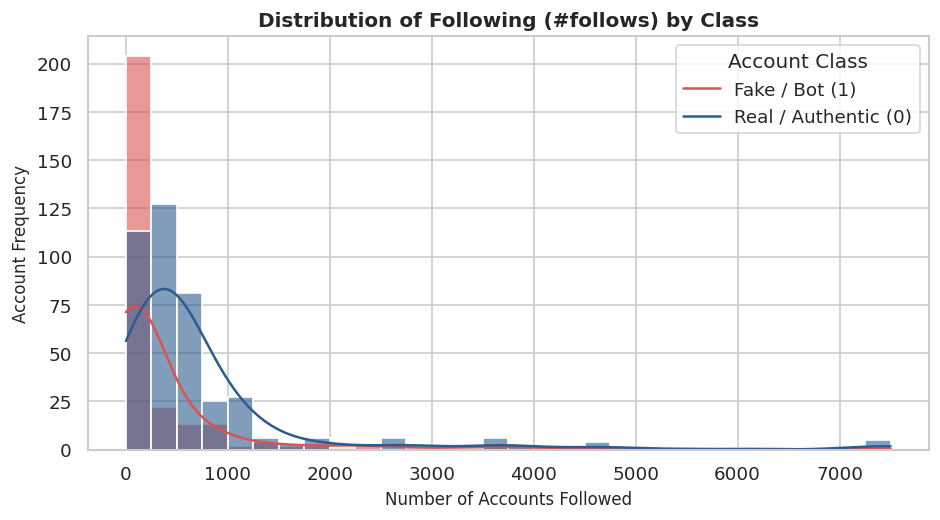

[SAVED] Follows distribution graph: /content/drive/MyDrive/Bot_Detection_Project/graphs/instagram/distribution_follows.png


In [62]:
# ==============================================================================
# GRAPH: DISTRIBUTION — FOLLOWS (FOLLOWING) COUNT
# ==============================================================================
plt.figure(figsize=(8, 4.5))
col_follows = '#follows' if '#follows' in df_clean.columns else [c for c in numerical_features if 'follow' in c.lower() and c != col_followers][0]

sns.histplot(data=df_clean, x=col_follows, hue=target_col, kde=True,
             palette={0: '#2b5c8f', 1: '#d9534f'}, bins=30, alpha=0.6)
plt.title(f"Distribution of Following ({col_follows}) by Class", fontsize=12, fontweight='bold')
plt.xlabel("Number of Accounts Followed", fontsize=10)
plt.ylabel("Account Frequency", fontsize=10)
plt.legend(title='Account Class', labels=['Fake / Bot (1)', 'Real / Authentic (0)'])
plt.tight_layout()

dist_follows_path = os.path.join(GRAPH_PATH, "distribution_follows.png")
plt.savefig(dist_follows_path, dpi=300)
plt.show()
plt.close()
print(f"[SAVED] Follows distribution graph: {dist_follows_path}")

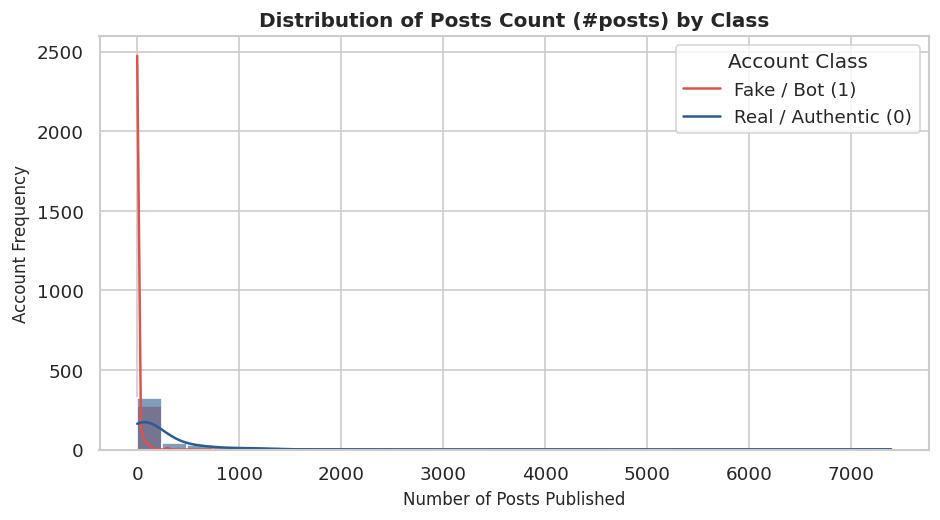

[SAVED] Posts distribution graph: /content/drive/MyDrive/Bot_Detection_Project/graphs/instagram/distribution_posts.png


In [63]:
# ==============================================================================
# GRAPH: DISTRIBUTION — POSTS COUNT
# ==============================================================================
plt.figure(figsize=(8, 4.5))
col_posts = '#posts' if '#posts' in df_clean.columns else [c for c in numerical_features if 'post' in c.lower()][0]

sns.histplot(data=df_clean, x=col_posts, hue=target_col, kde=True,
             palette={0: '#2b5c8f', 1: '#d9534f'}, bins=30, alpha=0.6)
plt.title(f"Distribution of Posts Count ({col_posts}) by Class", fontsize=12, fontweight='bold')
plt.xlabel("Number of Posts Published", fontsize=10)
plt.ylabel("Account Frequency", fontsize=10)
plt.legend(title='Account Class', labels=['Fake / Bot (1)', 'Real / Authentic (0)'])
plt.tight_layout()

dist_posts_path = os.path.join(GRAPH_PATH, "distribution_posts.png")
plt.savefig(dist_posts_path, dpi=300)
plt.show()
plt.close()
print(f"[SAVED] Posts distribution graph: {dist_posts_path}")

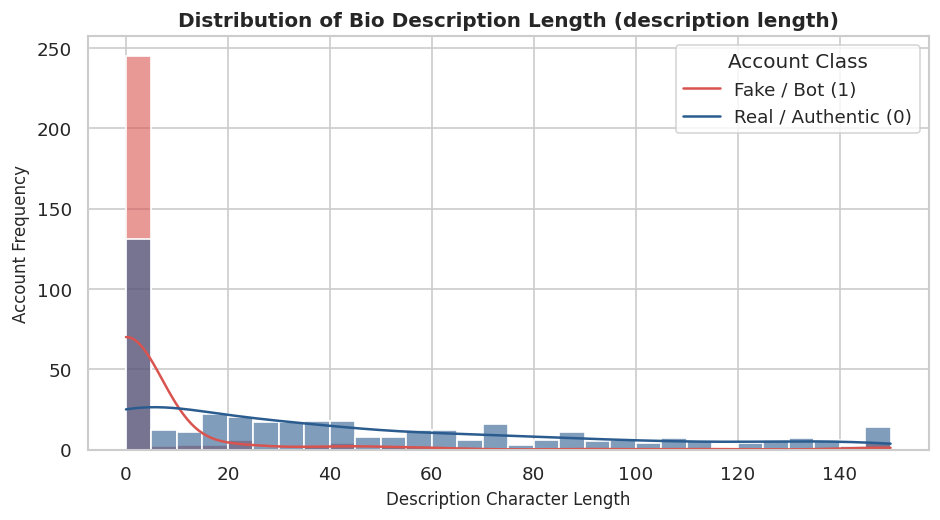

[SAVED] Description length distribution graph: /content/drive/MyDrive/Bot_Detection_Project/graphs/instagram/distribution_description_length.png


In [64]:
# ==============================================================================
# GRAPH: DISTRIBUTION — DESCRIPTION LENGTH
# ==============================================================================
plt.figure(figsize=(8, 4.5))
col_desc = 'description length' if 'description length' in df_clean.columns else [c for c in numerical_features if 'desc' in c.lower()][0]

sns.histplot(data=df_clean, x=col_desc, hue=target_col, kde=True,
             palette={0: '#2b5c8f', 1: '#d9534f'}, bins=30, alpha=0.6)
plt.title(f"Distribution of Bio Description Length ({col_desc})", fontsize=12, fontweight='bold')
plt.xlabel("Description Character Length", fontsize=10)
plt.ylabel("Account Frequency", fontsize=10)
plt.legend(title='Account Class', labels=['Fake / Bot (1)', 'Real / Authentic (0)'])
plt.tight_layout()

dist_desc_path = os.path.join(GRAPH_PATH, "distribution_description_length.png")
plt.savefig(dist_desc_path, dpi=300)
plt.show()
plt.close()
print(f"[SAVED] Description length distribution graph: {dist_desc_path}")

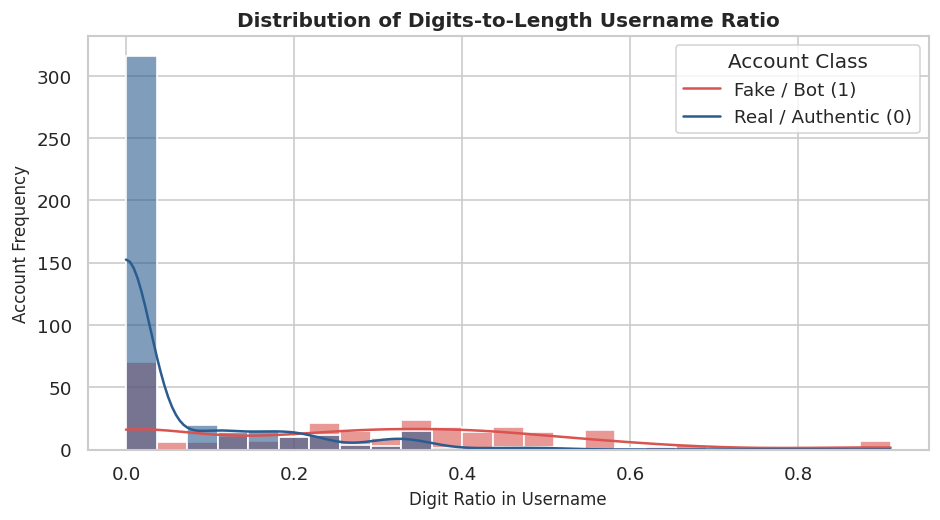

[SAVED] Username digits distribution graph: /content/drive/MyDrive/Bot_Detection_Project/graphs/instagram/distribution_username_digits.png


In [65]:
# ==============================================================================
# GRAPH: DISTRIBUTION — NUMS/LENGTH USERNAME RATIO
# ==============================================================================
plt.figure(figsize=(8, 4.5))
col_username_digits = 'nums/length username' if 'nums/length username' in df_clean.columns else [c for c in numerical_features if 'username' in c.lower()][0]

sns.histplot(data=df_clean, x=col_username_digits, hue=target_col, kde=True,
             palette={0: '#2b5c8f', 1: '#d9534f'}, bins=25, alpha=0.6)
plt.title("Distribution of Digits-to-Length Username Ratio", fontsize=12, fontweight='bold')
plt.xlabel("Digit Ratio in Username", fontsize=10)
plt.ylabel("Account Frequency", fontsize=10)
plt.legend(title='Account Class', labels=['Fake / Bot (1)', 'Real / Authentic (0)'])
plt.tight_layout()

dist_user_digits_path = os.path.join(GRAPH_PATH, "distribution_username_digits.png")
plt.savefig(dist_user_digits_path, dpi=300)
plt.show()
plt.close()
print(f"[SAVED] Username digits distribution graph: {dist_user_digits_path}")

---
## 9. Feature Boxplot Analysis across Classes
Examine feature dispersion, median shifts, and outliers between authentic and fake profiles.

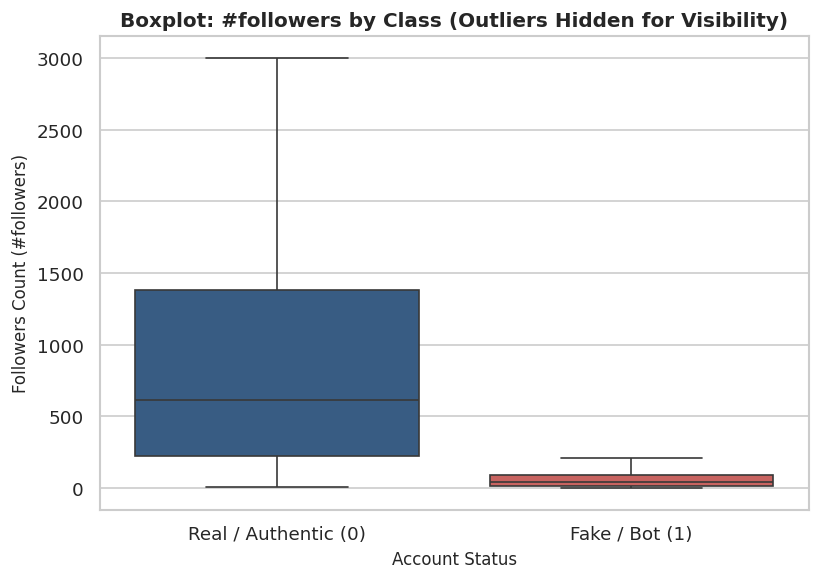

[SAVED] Followers boxplot: /content/drive/MyDrive/Bot_Detection_Project/graphs/instagram/02_boxplot_followers.png


In [66]:
# ==============================================================================
# GRAPH: BOXPLOT — FOLLOWERS COUNT ACROSS TARGET CLASSES
# ==============================================================================
plt.figure(figsize=(7, 5))
palette = ['#2b5c8f', '#d9534f']
sns.boxplot(data=df_clean, x=target_col, y=col_followers, palette=palette, showfliers=False)
plt.title(f"Boxplot: {col_followers} by Class (Outliers Hidden for Visibility)", fontsize=12, fontweight='bold')
plt.xlabel("Account Status", fontsize=10)
plt.ylabel(f"Followers Count ({col_followers})", fontsize=10)
plt.xticks(ticks=[0, 1], labels=['Real / Authentic (0)', 'Fake / Bot (1)'])
plt.tight_layout()

box_followers_path = os.path.join(GRAPH_PATH, "02_boxplot_followers.png")
plt.savefig(box_followers_path, dpi=300)
plt.show()
plt.close()
print(f"[SAVED] Followers boxplot: {box_followers_path}")

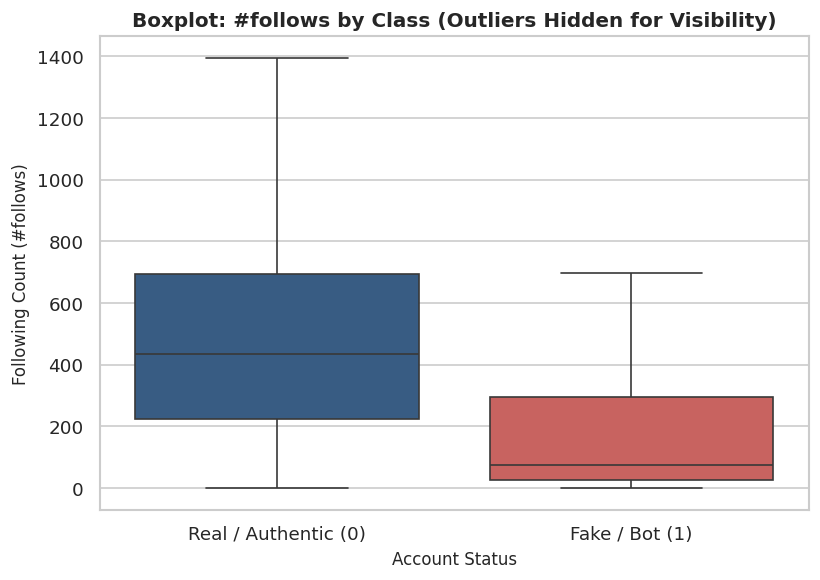

[SAVED] Follows boxplot: /content/drive/MyDrive/Bot_Detection_Project/graphs/instagram/03_boxplot_follows.png


In [67]:
# ==============================================================================
# GRAPH: BOXPLOT — FOLLOWS (FOLLOWING) COUNT ACROSS TARGET CLASSES
# ==============================================================================
plt.figure(figsize=(7, 5))
palette = ['#2b5c8f', '#d9534f']
sns.boxplot(data=df_clean, x=target_col, y=col_follows, palette=palette, showfliers=False)
plt.title(f"Boxplot: {col_follows} by Class (Outliers Hidden for Visibility)", fontsize=12, fontweight='bold')
plt.xlabel("Account Status", fontsize=10)
plt.ylabel(f"Following Count ({col_follows})", fontsize=10)
plt.xticks(ticks=[0, 1], labels=['Real / Authentic (0)', 'Fake / Bot (1)'])
plt.tight_layout()

box_follows_path = os.path.join(GRAPH_PATH, "03_boxplot_follows.png")
plt.savefig(box_follows_path, dpi=300)
plt.show()
plt.close()
print(f"[SAVED] Follows boxplot: {box_follows_path}")

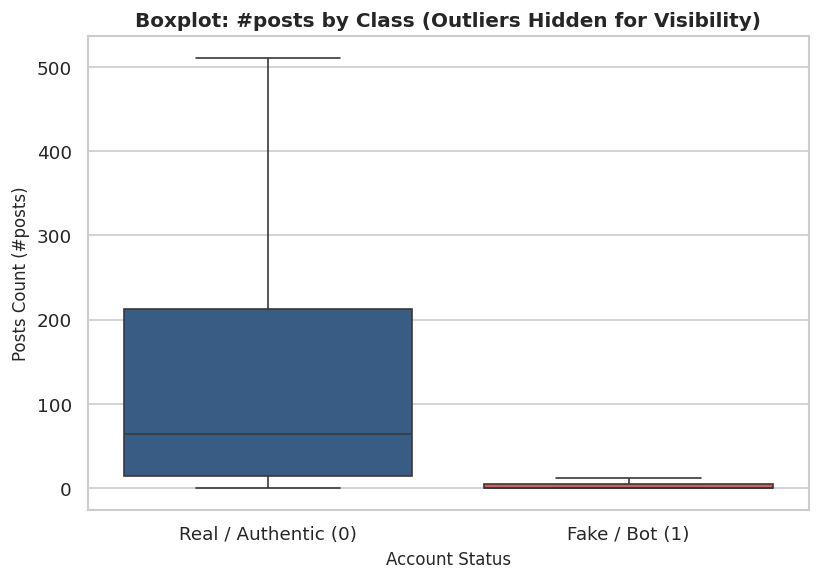

[SAVED] Posts boxplot: /content/drive/MyDrive/Bot_Detection_Project/graphs/instagram/04_boxplot_posts.png


In [68]:
# ==============================================================================
# GRAPH: BOXPLOT — POSTS COUNT ACROSS TARGET CLASSES
# ==============================================================================
plt.figure(figsize=(7, 5))
palette = ['#2b5c8f', '#d9534f']
sns.boxplot(data=df_clean, x=target_col, y=col_posts, palette=palette, showfliers=False)
plt.title(f"Boxplot: {col_posts} by Class (Outliers Hidden for Visibility)", fontsize=12, fontweight='bold')
plt.xlabel("Account Status", fontsize=10)
plt.ylabel(f"Posts Count ({col_posts})", fontsize=10)
plt.xticks(ticks=[0, 1], labels=['Real / Authentic (0)', 'Fake / Bot (1)'])
plt.tight_layout()

box_posts_path = os.path.join(GRAPH_PATH, "04_boxplot_posts.png")
plt.savefig(box_posts_path, dpi=300)
plt.show()
plt.close()
print(f"[SAVED] Posts boxplot: {box_posts_path}")

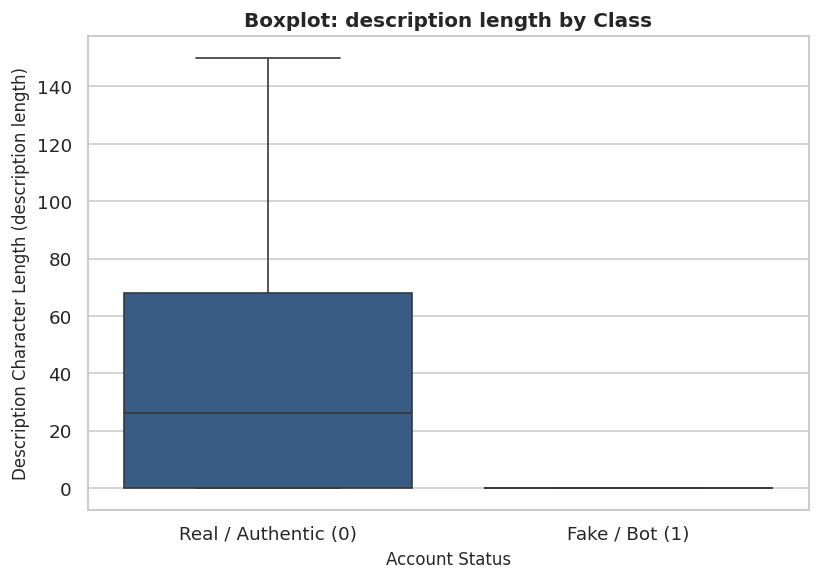

[SAVED] Description length boxplot: /content/drive/MyDrive/Bot_Detection_Project/graphs/instagram/05_boxplot_description_length.png


In [69]:
# ==============================================================================
# GRAPH: BOXPLOT — DESCRIPTION LENGTH ACROSS TARGET CLASSES
# ==============================================================================
plt.figure(figsize=(7, 5))
palette = ['#2b5c8f', '#d9534f']
sns.boxplot(data=df_clean, x=target_col, y=col_desc, palette=palette, showfliers=False)
plt.title(f"Boxplot: {col_desc} by Class", fontsize=12, fontweight='bold')
plt.xlabel("Account Status", fontsize=10)
plt.ylabel(f"Description Character Length ({col_desc})", fontsize=10)
plt.xticks(ticks=[0, 1], labels=['Real / Authentic (0)', 'Fake / Bot (1)'])
plt.tight_layout()

box_desc_path = os.path.join(GRAPH_PATH, "05_boxplot_description_length.png")
plt.savefig(box_desc_path, dpi=300)
plt.show()
plt.close()
print(f"[SAVED] Description length boxplot: {box_desc_path}")

---
## 12. Preprocessing & Zero-Leakage Train/Test Split
Separate features and target, execute a stratified 80/20 train/test split, and fit feature scalers strictly on training data.

In [75]:
# ==============================================================================
# PREPROCESSING & ZERO-LEAKAGE STRATIFIED TRAIN/TEST SPLIT
# ==============================================================================
# 1. Feature matrix X and ground truth vector y
X = df_clean[all_features].copy()
y = df_clean[target_col].copy()

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape  : {y.shape}")
print("Target Class Mapping: 0 = Real / Authentic Account, 1 = Fake / Bot Account")

# 2. Stratified Train/Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

print(f"\nTrain set shape : X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"Test set shape  : X_test : {X_test.shape}, y_test : {y_test.shape}")
print(f"Train class balance: Real={sum(y_train==0)}, Fake={sum(y_train==1)}")
print(f"Test class balance : Real={sum(y_test==0)}, Fake={sum(y_test==1)}")

# 3. Prevent Data Leakage: Fit StandardScaler ONLY on Training Set
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Convert scaled arrays back to DataFrames for interpretability
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=all_features)
X_test_scaled_df  = pd.DataFrame(X_test_scaled, columns=all_features)

# Initialize master results repository
model_results = {}
test_probabilities = {}

print("\n[SUCCESS] Feature scaling fitted strictly on training data. Zero data leakage verified.")

Features (X) shape: (692, 11)
Target (y) shape  : (692,)
Target Class Mapping: 0 = Real / Authentic Account, 1 = Fake / Bot Account

Train set shape : X_train: (553, 11), y_train: (553,)
Test set shape  : X_test : (139, 11), y_test : (139,)
Train class balance: Real=332, Fake=221
Test class balance : Real=83, Fake=56

[SUCCESS] Feature scaling fitted strictly on training data. Zero data leakage verified.


---
## 13. Machine Learning: Logistic Regression
Train a linear classifier with L2 regularization on standard-scaled features.

In [76]:
# ==============================================================================
# MODEL 1: LOGISTIC REGRESSION
# ==============================================================================
lr_model = LogisticRegression(max_iter=1000, random_state=SEED)
lr_model.fit(X_train_scaled, y_train)

# Inference on held-out test partition
y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]
test_probabilities['Logistic Regression'] = y_prob_lr

# Performance evaluation metrics
acc_lr  = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr, zero_division=0)
rec_lr  = recall_score(y_test, y_pred_lr, zero_division=0)
f1_lr   = f1_score(y_test, y_pred_lr, zero_division=0)

model_results['Logistic Regression'] = {
    'Accuracy': acc_lr,
    'Precision': prec_lr,
    'Recall': rec_lr,
    'F1 Score': f1_lr
}

print("=== Logistic Regression Performance ===")
print(f"  Accuracy  : {acc_lr:.4f}")
print(f"  Precision : {prec_lr:.4f}")
print(f"  Recall    : {rec_lr:.4f}")
print(f"  F1 Score  : {f1_lr:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['Real (0)', 'Fake (1)']))

# Save trained model artifact
lr_model_path = os.path.join(MODEL_PATH, "logistic_regression.pkl")
joblib.dump(lr_model, lr_model_path)
print(f"[SAVED] Model artifact: {lr_model_path}")

=== Logistic Regression Performance ===
  Accuracy  : 0.8705
  Precision : 0.8958
  Recall    : 0.7679
  F1 Score  : 0.8269

Classification Report:
              precision    recall  f1-score   support

    Real (0)       0.86      0.94      0.90        83
    Fake (1)       0.90      0.77      0.83        56

    accuracy                           0.87       139
   macro avg       0.88      0.85      0.86       139
weighted avg       0.87      0.87      0.87       139

[SAVED] Model artifact: /content/drive/MyDrive/Bot_Detection_Project/models/instagram/logistic_regression.pkl


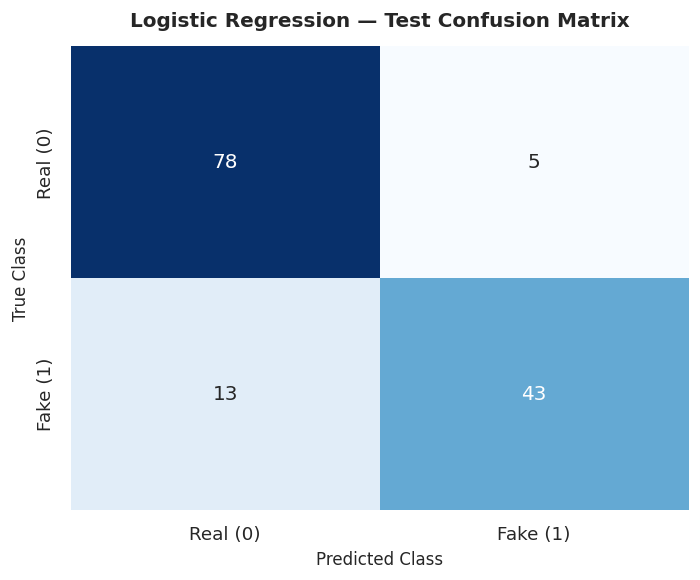

[SAVED] Logistic Regression confusion matrix: /content/drive/MyDrive/Bot_Detection_Project/graphs/instagram/logistic_confusion_matrix.png


In [77]:
# ==============================================================================
# GRAPH: CONFUSION MATRIX — LOGISTIC REGRESSION
# ==============================================================================
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Real (0)', 'Fake (1)'], yticklabels=['Real (0)', 'Fake (1)'])
plt.title("Logistic Regression — Test Confusion Matrix", fontsize=12, fontweight='bold', pad=12)
plt.xlabel("Predicted Class", fontsize=10)
plt.ylabel("True Class", fontsize=10)
plt.tight_layout()

cm_lr_path = os.path.join(GRAPH_PATH, "logistic_confusion_matrix.png")
plt.savefig(cm_lr_path, dpi=300)
plt.show()
plt.close()
print(f"[SAVED] Logistic Regression confusion matrix: {cm_lr_path}")

---
## 14. Machine Learning: Random Forest & Feature Importance
Train an ensemble of 100 decision trees and evaluate non-linear feature split importances.

In [78]:
# ==============================================================================
# MODEL 2: RANDOM FOREST CLASSIFIER
# ==============================================================================
rf_model = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Inference on test partition
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]
test_probabilities['Random Forest'] = y_prob_rf

# Calculate evaluation metrics
acc_rf  = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf, zero_division=0)
rec_rf  = recall_score(y_test, y_pred_rf, zero_division=0)
f1_rf   = f1_score(y_test, y_pred_rf, zero_division=0)

model_results['Random Forest'] = {
    'Accuracy': acc_rf,
    'Precision': prec_rf,
    'Recall': rec_rf,
    'F1 Score': f1_rf
}

print("=== Random Forest Performance ===")
print(f"  Accuracy  : {acc_rf:.4f}")
print(f"  Precision : {prec_rf:.4f}")
print(f"  Recall    : {rec_rf:.4f}")
print(f"  F1 Score  : {f1_rf:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Real (0)', 'Fake (1)']))

# Save trained model artifact
rf_model_path = os.path.join(MODEL_PATH, "random_forest.pkl")
joblib.dump(rf_model, rf_model_path)
print(f"[SAVED] Model artifact: {rf_model_path}")

# Calculate feature importance
rf_importance_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

rf_imp_csv_path = os.path.join(RESULT_PATH, "random_forest_feature_importance.csv")
rf_importance_df.to_csv(rf_imp_csv_path, index=False)
print(f"[SAVED] Feature importance table: {rf_imp_csv_path}")

=== Random Forest Performance ===
  Accuracy  : 0.9424
  Precision : 1.0000
  Recall    : 0.8571
  F1 Score  : 0.9231

Classification Report:
              precision    recall  f1-score   support

    Real (0)       0.91      1.00      0.95        83
    Fake (1)       1.00      0.86      0.92        56

    accuracy                           0.94       139
   macro avg       0.96      0.93      0.94       139
weighted avg       0.95      0.94      0.94       139

[SAVED] Model artifact: /content/drive/MyDrive/Bot_Detection_Project/models/instagram/random_forest.pkl
[SAVED] Feature importance table: /content/drive/MyDrive/Bot_Detection_Project/results/instagram/random_forest_feature_importance.csv


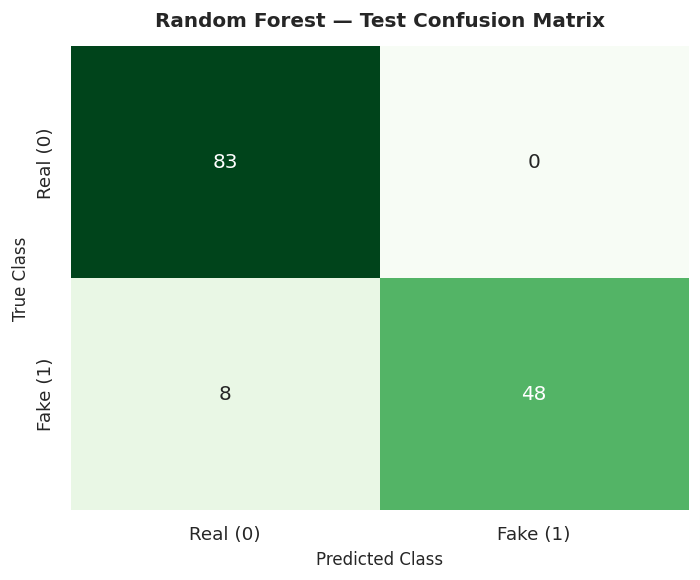

[SAVED] Random Forest confusion matrix: /content/drive/MyDrive/Bot_Detection_Project/graphs/instagram/random_forest_confusion_matrix.png


In [79]:
# ==============================================================================
# GRAPH: CONFUSION MATRIX — RANDOM FOREST
# ==============================================================================
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Real (0)', 'Fake (1)'], yticklabels=['Real (0)', 'Fake (1)'])
plt.title("Random Forest — Test Confusion Matrix", fontsize=12, fontweight='bold', pad=12)
plt.xlabel("Predicted Class", fontsize=10)
plt.ylabel("True Class", fontsize=10)
plt.tight_layout()

cm_rf_path = os.path.join(GRAPH_PATH, "random_forest_confusion_matrix.png")
plt.savefig(cm_rf_path, dpi=300)
plt.show()
plt.close()
print(f"[SAVED] Random Forest confusion matrix: {cm_rf_path}")

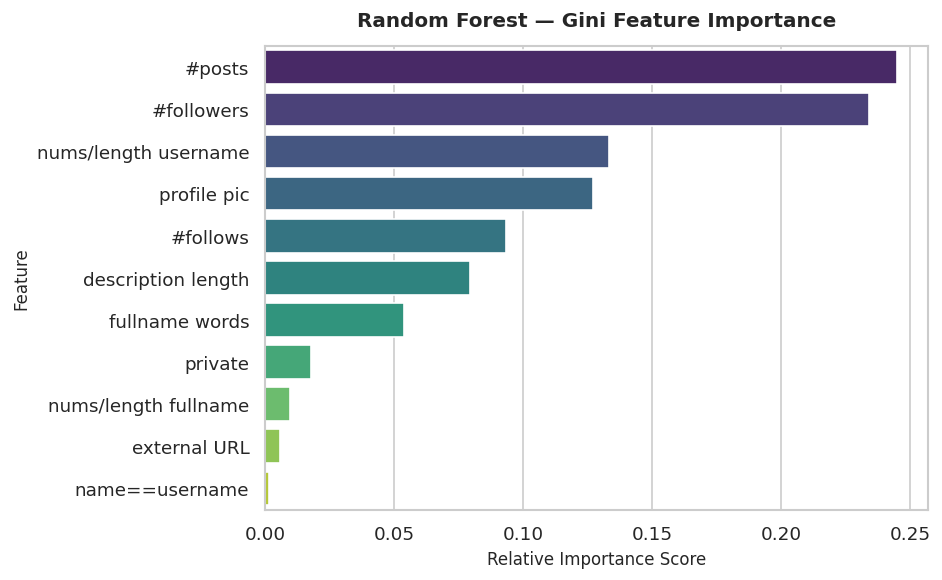

[SAVED] Random Forest feature importance graph: /content/drive/MyDrive/Bot_Detection_Project/graphs/instagram/random_forest_feature_importance.png


In [80]:
# ==============================================================================
# GRAPH: FEATURE IMPORTANCE — RANDOM FOREST
# ==============================================================================
plt.figure(figsize=(8, 5))
sns.barplot(data=rf_importance_df, x='Importance', y='Feature', palette='viridis')
plt.title("Random Forest — Gini Feature Importance", fontsize=12, fontweight='bold', pad=12)
plt.xlabel("Relative Importance Score", fontsize=10)
plt.ylabel("Feature", fontsize=10)
plt.tight_layout()

rf_imp_graph_path = os.path.join(GRAPH_PATH, "random_forest_feature_importance.png")
plt.savefig(rf_imp_graph_path, dpi=300)
plt.show()
plt.close()
print(f"[SAVED] Random Forest feature importance graph: {rf_imp_graph_path}")

---
## 18. Receiver Operating Characteristic (ROC) & AUC Comparison
Compute True Positive Rates vs False Positive Rates across classification thresholds.

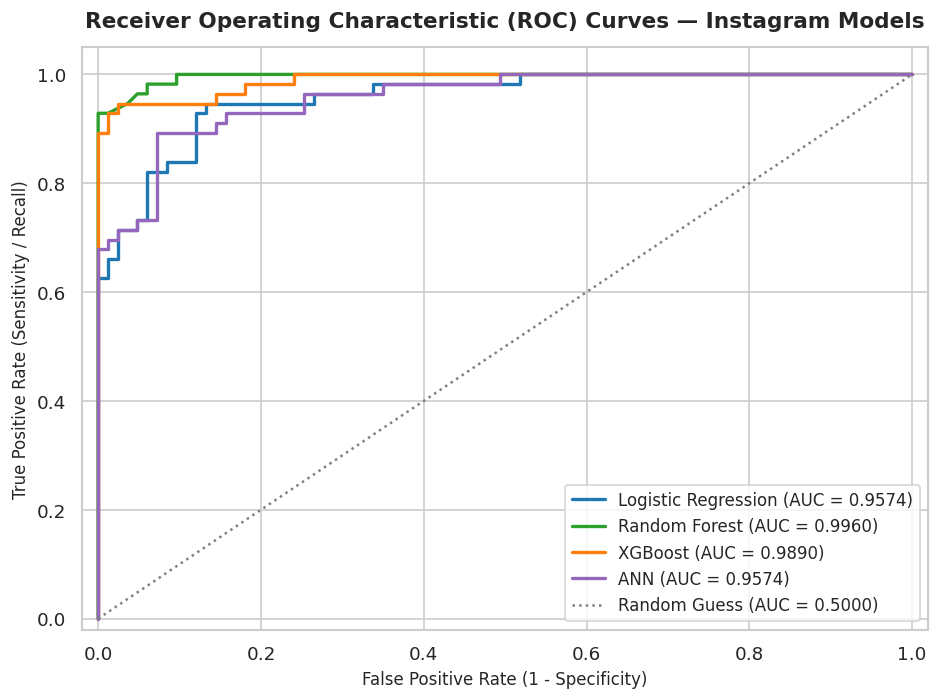

[SAVED] ROC comparison graph: /content/drive/MyDrive/Bot_Detection_Project/graphs/instagram/roc_curve_comparison.png
[SAVED] ROC-AUC summary table: /content/drive/MyDrive/Bot_Detection_Project/results/instagram/model_roc_auc_scores.csv
                 Model  ROC_AUC
0        Random Forest   0.9960
1              XGBoost   0.9890
2  Logistic Regression   0.9574
3                  ANN   0.9574


In [91]:
# ==============================================================================
# GRAPH: MULTI-MODEL ROC CURVES & AUC BENCHMARKING
# ==============================================================================
plt.figure(figsize=(8, 6))

roc_auc_records = []
colors = {'Logistic Regression': '#1f77b4', 'Random Forest': '#2ca02c', 'XGBoost': '#ff7f0e', 'ANN': '#9467bd'}

for model_name, y_probs in test_probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    auc_score = roc_auc_score(y_test, y_probs)
    roc_auc_records.append({'Model': model_name, 'ROC_AUC': round(auc_score, 4)})
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {auc_score:.4f})", lw=2, color=colors.get(model_name, 'black'))

plt.plot([0, 1], [0, 1], color='gray', linestyle=':', lw=1.5, label='Random Guess (AUC = 0.5000)')
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.05])
plt.title("Receiver Operating Characteristic (ROC) Curves — Instagram Models", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("False Positive Rate (1 - Specificity)", fontsize=10)
plt.ylabel("True Positive Rate (Sensitivity / Recall)", fontsize=10)
plt.legend(loc="lower right", fontsize=10)
plt.tight_layout()

roc_graph_path = os.path.join(GRAPH_PATH, "roc_curve_comparison.png")
plt.savefig(roc_graph_path, dpi=300)
plt.show()
plt.close()
print(f"[SAVED] ROC comparison graph: {roc_graph_path}")

# Save ROC-AUC Scores Table
roc_df = pd.DataFrame(roc_auc_records).sort_values(by='ROC_AUC', ascending=False).reset_index(drop=True)
roc_csv_path = os.path.join(RESULT_PATH, "model_roc_auc_scores.csv")
roc_df.to_csv(roc_csv_path, index=False)
print(f"[SAVED] ROC-AUC summary table: {roc_csv_path}")
print(roc_df)